# 🐍 Python Level 3 - Advanced course
## Class 1 — Databases with SQLite
### 📝 Practice Exercises — Solutions

**Python instructor - Catarina Santos**

---

<div style="display:inline-flex; align-items:center; gap:28px; background:#FFFFFF; color:#1D1D1B; padding:10px 14px; border-radius:8px; margin-bottom:8px;">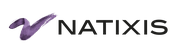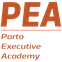</div>

---

---

| Section | Difficulty | Topics |
|---------|------------|--------|
| A | 🟢 Warm-up | connect, create, insert, select |
| B | 🟡 Core practice | `WHERE`, `ORDER BY`, `LIMIT`, placeholders |
| C | 🟠 Applied | `UPDATE`, `DELETE`, `GROUP BY` |
| D | 🔴 Challenge | a small store, and pandas both ways |

> 💡 These are **one** correct answer each. SQL usually has several ways to ask the same
> question — if yours returns the same rows, it is right.

---

## ⚙️ Setup

In [ ]:
import sqlite3
import pandas as pd

books = [
    ("The Long Road",  "Ana Silva",     2019, 720, 24.50, "available"),
    ("Python Basics",  "Bruno Costa",   2023, 180,  19.90, "on loan"),
    ("Atlas of Ports", "Clara Dias",    2015, 640,  45.00, "available"),
    ("Short Stories",  "Ana Silva",     2021,  95,   9.99, "on loan"),
    ("Deep Water",     "Diogo Melo",    2018, 412,  15.50, "available"),
    ("City Lights",    "Bruno Costa",   2022, 260,  22.00, "lost"),
    ("The Quiet Bay",  "Ana Silva",     2020, 330,  18.75, "available"),
]

print("Setup complete:", len(books), "books to load")

---
## 🟢 Section A — Warm-up

> 🕐 Estimated time: 15 min

### Exercise A1 — Connect and create a table

In [ ]:
# A1 - IF NOT EXISTS so the cell can be re-run; DELETE FROM so rows do not pile up
connection = sqlite3.connect("library.db")
cursor = connection.cursor()

cursor.execute("""
    CREATE TABLE IF NOT EXISTS books (
        title  TEXT,
        author TEXT,
        year   INTEGER,
        pages  INTEGER,
        price  REAL,
        status TEXT
    )
""")

cursor.execute("DELETE FROM books")
connection.commit()

print("Table ready")

### Exercise A2 — Insert the books

In [ ]:
# A2 - one ? per column, and executemany runs it once per row
cursor.executemany("INSERT INTO books VALUES (?, ?, ?, ?, ?, ?)", books)
connection.commit()

print("Rows inserted:", cursor.rowcount)

### Exercise A3 — Read everything back

In [ ]:
# A3 - fetchall() gives a list of tuples, one per row
cursor.execute("SELECT * FROM books")
for row in cursor.fetchall():
    print(row)

### Exercise A4 — Count the rows

In [ ]:
# A4 - COUNT(*) comes back as a one-value tuple, so [0] takes the number out
cursor.execute("SELECT COUNT(*) FROM books")
print("Books in the table:", cursor.fetchone()[0])

---
## 🟡 Section B — Core practice

> 🕐 Estimated time: 25 min

### Exercise B1 — Choose columns and rows

In [ ]:
# B1 - name the columns you want, and WHERE picks the rows
cursor.execute("SELECT title, author FROM books WHERE status = 'available'")
for title, author in cursor.fetchall():
    print(f"{title:<16}{author}")

### Exercise B2 — Sort, and take the top few

In [ ]:
# B2 - ORDER BY ... DESC for biggest first, LIMIT for only the first few
cursor.execute("SELECT title, pages FROM books ORDER BY pages DESC LIMIT 3")
for title, pages in cursor.fetchall():
    print(f"{title:<16}{pages:>5}")

print()
cursor.execute("SELECT title, price FROM books ORDER BY price ASC LIMIT 1")
print("Cheapest:", cursor.fetchone())

### Exercise B3 — Two conditions

In [ ]:
# B3 - AND joins two conditions, exactly like Python's and
cursor.execute("""
    SELECT title, year, status
    FROM books
    WHERE year >= 2020 AND status = 'available'
""")
for row in cursor.fetchall():
    print(row)

### Exercise B4 — Use a placeholder

In [ ]:
# B4 - the value goes in as a ?, never glued into the string.
# Note the comma: the values are a tuple, even when there is only one.
def books_by(author):
    """Print the titles by one author."""
    cursor.execute("SELECT title, year FROM books WHERE author = ?", (author,))
    for title, year in cursor.fetchall():
        print(f"{title:<16}{year}")

books_by("Ana Silva")
print()
books_by("Bruno Costa")

---
## 🟠 Section C — Applied

> 🕐 Estimated time: 25 min

### Exercise C1 — Update a row

In [ ]:
# C1 - look first with a SELECT, change, then look again
cursor.execute("SELECT title, status FROM books WHERE title = ?", ("Python Basics",))
print("Before:", cursor.fetchone())

cursor.execute("UPDATE books SET status = ? WHERE title = ?", ("available", "Python Basics"))
connection.commit()

cursor.execute("SELECT title, status FROM books WHERE title = ?", ("Python Basics",))
print("After :", cursor.fetchone())

### Exercise C2 — Delete rows

In [ ]:
# C2 - always check what a DELETE will hit before running it
cursor.execute("SELECT title FROM books WHERE status = 'lost'")
print("Will delete:", cursor.fetchall())

cursor.execute("DELETE FROM books WHERE status = ?", ("lost",))
connection.commit()
print("Rows deleted:", cursor.rowcount)

cursor.execute("SELECT COUNT(*) FROM books")
print("Rows left   :", cursor.fetchone()[0])

### Exercise C3 — Summarise the whole table

In [ ]:
# C3 - SQL does the arithmetic and sends back one row
cursor.execute("SELECT COUNT(*), SUM(pages), AVG(price), MAX(price) FROM books")
count, total_pages, average_price, dearest = cursor.fetchone()

print(f"Books        : {count}")
print(f"Total pages  : {total_pages}")
print(f"Average price: {average_price:.2f}")
print(f"Dearest      : {dearest:.2f}")

### Exercise C4 — Summarise per author

In [ ]:
# C4 - GROUP BY is SQL's version of pandas .groupby(), and AS names the result
cursor.execute("""
    SELECT author, COUNT(*) AS books, SUM(pages) AS pages
    FROM books
    GROUP BY author
    ORDER BY pages DESC
""")

print(f"{'author':<14}{'books':>6}{'pages':>8}")
for author, number, pages in cursor.fetchall():
    print(f"{author:<14}{number:>6}{pages:>8}")

---
## 🔴 Section D — Challenge

> 🕐 Estimated time: 25 min

### Exercise D1 — A borrowing session

In [ ]:
# D1 - the whole sequence: read, change, read again
def show(label):
    """Print every book with its status, under a label."""
    print(label)
    cursor.execute("SELECT title, status FROM books ORDER BY title")
    for title, status in cursor.fetchall():
        print(f"  {title:<16}{status}")
    print()

show("BEFORE")

cursor.execute("UPDATE books SET status = ? WHERE title = ?", ("on loan", "Deep Water"))
cursor.execute("UPDATE books SET status = ? WHERE title = ?", ("available", "Short Stories"))
cursor.execute("INSERT INTO books VALUES (?, ?, ?, ?, ?, ?)",
               ("New Arrival", "Eva Nunes", 2024, 210, 21.50, "available"))
connection.commit()

show("AFTER")

cursor.execute("SELECT status, COUNT(*) FROM books GROUP BY status ORDER BY status")
print(f"{'status':<12}{'count':>6}")
for status, number in cursor.fetchall():
    print(f"{status:<12}{number:>6}")

### Exercise D2 — pandas both ways

In [ ]:
# D2 - SQL narrows the data down, pandas does the analysis
available = pd.read_sql_query(
    "SELECT title, author, pages, price FROM books WHERE status = 'available'",
    connection,
)
print(available)
print()
print("Available books :", len(available))
print("Average price   :", round(available["price"].mean(), 2))

# ... and back the other way, into a new table
available["value_per_page"] = (available["price"] / available["pages"]).round(4)
available.to_sql("available_books", connection, if_exists="replace", index=False)

check = pd.read_sql_query(
    "SELECT title, value_per_page FROM available_books ORDER BY value_per_page DESC LIMIT 3",
    connection,
)
print()
print(check)

connection.commit()
connection.close()
print()
print("Closed.")

---

### 🎉 Well done!

| | Concept | Exercises |
|-|---------|----------|
| ✅ | `connect`, `cursor`, `commit` | A1 |
| ✅ | `CREATE TABLE IF NOT EXISTS` | A1 |
| ✅ | `INSERT` and `executemany` | A2, D1 |
| ✅ | `SELECT` and `fetchall` | A3, B1 |
| ✅ | `COUNT` and `fetchone` | A4, C3 |
| ✅ | `WHERE`, and two conditions with `AND` | B1, B3 |
| ✅ | `ORDER BY` and `LIMIT` | B2 |
| ✅ | `?` placeholders | B4, C1, C2, D1 |
| ✅ | `UPDATE` | C1, D1 |
| ✅ | `DELETE` | C2 |
| ✅ | `SUM`, `AVG`, `MAX` | C3 |
| ✅ | `GROUP BY` and `AS` | C4, D1 |
| ✅ | `read_sql_query` and `to_sql` | D2 |
| ✅ | `close()` | D2 |

**The habit that will save you most:** before every `UPDATE` or `DELETE`, run the same `WHERE`
as a `SELECT` first and look at what comes back. C1, C2 and D1 all do it, and it costs one line.